# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 8. Вероятность


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 60 баллов
* Задача 2 &mdash; 40 баллов
* Задача 3 &mdash; 100 баллов

In [1]:
# Bot check

# HW_ID: fpmi_ad8
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
import scipy.stats as sps
from typing import Dict, List, Optional, Tuple

sns.set(style="whitegrid", palette="Set2")

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1, 2 ,3**
1. [ссылка](https://chatgpt.com/share/69d6e46a-1700-8393-8cfe-cda5380979e7)
    - использование разных цветов в графиках
    - написание комментариев и докстрингов (чисто оформление)

---
### Задача 1.

**При решении данной задачи можно использовать ИИ-инструменты только для построения графиков и оформления документации к коду. Использование ИИ-инструментов для решения контеста запрещено.**

Современные библиотеки для генерации используют алгоритмы вроде PCG64 (Permuted Congruential Generator-64), который достаточно быстро генерирует случайные 64-битные целые числа. Если их отнормировать на максимально возможное число ($2^{64}-1$), мы получим равномерное распределение $U(0, 1)$.

В рамках этой задачи для лучшего понимания взаимосвязей случайных величин мы пойдем другим путем. Будем предполагать, что у нас имеется только симметричная монета, один бросок которой моделирует случайную величину из бернуллиевского распределения с параметром $p = 0.5$.

In [3]:
# Создаем генератор случайных чисел
rng = np.random.default_rng()
# Фиксируем первые два аргумента функции rng.integers (low=0 и high=2)
coin = partial(rng.integers, 0, 2)

Вам предстоит написать собственные генераторы выборок из равномерного, нормального и экспоненциального распределений с заданными параметрами, используя в качестве основы исключительно броски правильной монеты. Совершать броски можно неограниченное количество раз. Тем не менее, поскольку лишние броски увеличивают время генерации, стоит использовать оптимальное количество бросков. За лишнее количество бросков могут быть сняты баллы.

**1.** Напишите функцию **`uniform`** генерации случайных величин из равномерного распределения на отрезке $[0, 1]$ с заданной точностью. Это можно сделать, записав случайную величину $\xi \sim U(0, 1)$ в двоичной системе системе счисления $\xi = 0,\xi_1\xi_2\xi_3...$. Тогда $\xi_i \sim Bern(1/2)$ и независимы в совокупности. Приближение заключается в том, что вместо генерации бесконечного количества $\xi_i$ мы полагаем $\xi = 0,\xi_1\xi_2\xi_3...\xi_n$.

Нужно реализовать функцию `uniform` так, чтобы она могла принимать на вход в качестве параметра `size` как число, так и объект `tuple` любой размерности, и возвращать объект `numpy.array` соответствующей размерности. Например, если `size=(10, 1, 5)`, то функция должна вернуть объект размера $10 \times 1 \times 5$. Аргумент `n_bits` отвечает за число $n$.

Также обратите внимание, что  функцию `coin` можно вызвать только один раз. Для совершения 10 бросков монеты используйте `coin(10)`, это считается одним вызовом функции. При реализации функций генерации нельзя использовать какие-либо циклы, а также функции `np.vectorize`, `np.apply_along_axis`, `np.fromiter` и подобные, это медленно и по сути является циклом. Используйте векторные функции `numpy`. При нарушении этих правил будут сниматься баллы.

In [4]:
def uniform(size: int | tuple = 1, n_bits: int = 50) -> float | np.ndarray:
    """
    Генерирует значения, приближённо распределённые как U(0, 1).

    Параметры
    ----------
    size : int | tuple
        Размер выходного массива.
    n_bits : int
        Число битов для построения одного значения.

    Возвращает
    ----------
    float | np.ndarray
        Одно значение или массив значений из [0, 1].
    """

    # Формируем размер с дополнительной осью из n_bits
    shape = (*(size if isinstance(size, tuple) else (size,)), n_bits)

    # Генерируем биты и переводим их в числа из [0, 1]
    return coin(shape).dot(2.0 ** -np.arange(1, n_bits + 1))

In [5]:
data = uniform(200) # Генерация данных

Cгенерируйте $200$ независимых случайных величин, постройте график плотности на отрезке $[-0.25, 1.25]$, а также гистограмму по сгенерированным случайным величинам. Для построения графика необходимо брать достаточно большое количество точек сетки.

In [6]:
def uniform_graph(data: np.ndarray):
    """
    Рисует гистограмму данных и плотность U[0, 1].

    Параметры
    ---------
    data : np.ndarray
        Данные для отображения.
    """

    # Сетка для теоретической плотности
    grid = np.linspace(-0.25, 1.25, 1010)

    # Отрисовка графика
    plt.figure(figsize=(8, 5))

    plt.hist(data, bins=50, density=True, label="Данные")

    plt.plot(
        grid,
        sps.uniform(scale=1).pdf(grid),
        lw=5,
        alpha=0.5,
        label="Плотность $U[0, 1]$",
        color="#FF3300",
    )

    plt.xlabel("Значение")
    plt.legend()

    plt.show()

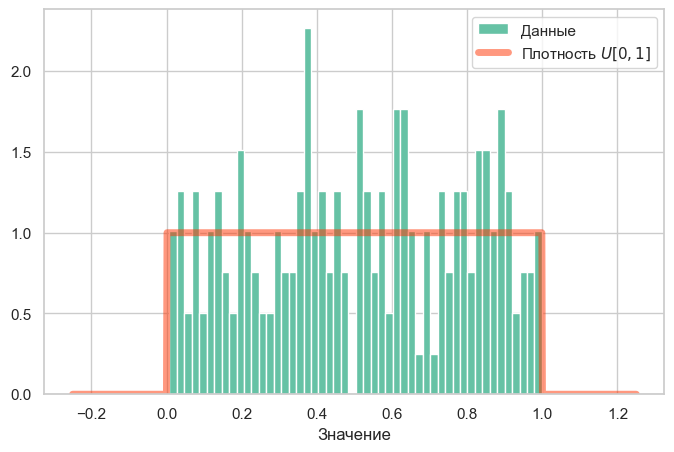

In [7]:
uniform_graph(uniform(200))

Исследуйте, как меняются значения случайных величин в зависимости от `n_bits` в написанной ранее вами функции.

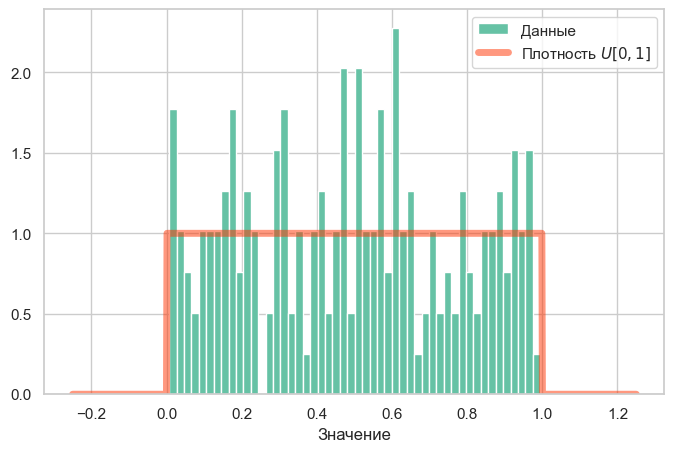

In [8]:
uniform_graph(uniform(200, n_bits=500))

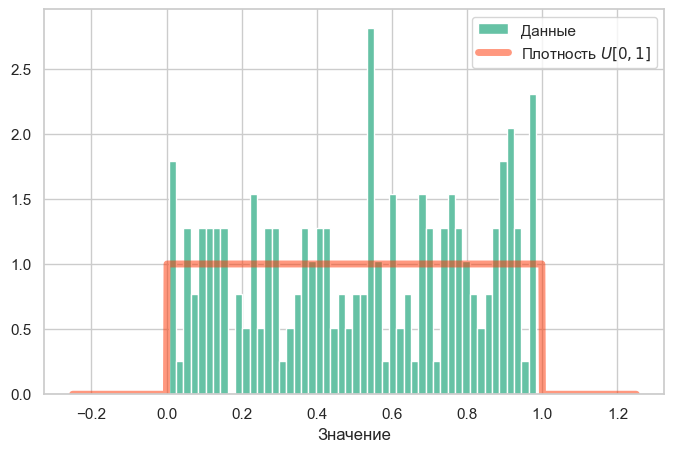

In [9]:
uniform_graph(uniform(200, n_bits=5000))

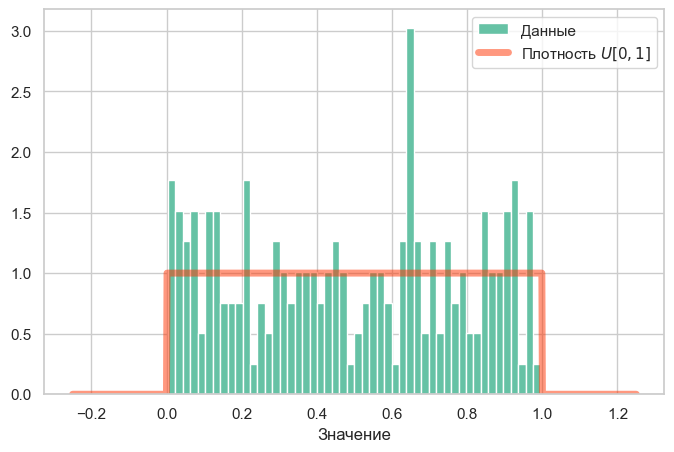

In [10]:
uniform_graph(uniform(200, n_bits=10))

Получаем, что распределение почти не зависит от значения `n_bits`, то есть при достаточно большом `n_bits = 50` увеличение уже не дает результата. То есть поправку которую дает `n_bits` настолько мала, что она не отображается на графике. Разница меньше чем `2^-n_bits`

**2.** Напишите функцию **`normal`** генерации случайных величин в количестве `size` штук из распределения $\mathcal{N}(loc, scale^2)$ с помощью преобразования Бокса-Мюллера. 

Реализация должна быть без циклов. В качестве параметра `size` может быть как число, так и объект `tuple` любой размерности. Можно использовать реализованную ранее функцию `uniform`.

При реализации `normal` допускается использовать количество бросков монеты чуть больше оптимального с целью упрощения кода. А именно, для генерации выборки размера $n$ можно использовать броски монет не более того количества, которое требуется для оптимальной генерации выборки размера $n+1$.

In [11]:
def normal(
    size: int | tuple = 1, loc: float = 0.0, scale: float = 1.0, n_bits: int = 50
) -> float | np.ndarray:
    """
    Генерирует значения из распределения N(loc, scale^2).

    Параметры
    ---------
    size : int | tuple
        Размер выходного массива.
    loc : float
        Среднее.
    scale : float
        Стандартное отклонение.
    n_bits : int
        Число битов для генерации U(0, 1).

    Возвращает
    ----------
    float | np.ndarray
        Одно значение или массив значений.
    """

    # Приводим размер к кортежу
    size = size if isinstance(size, tuple) else (size,)

    # Считаем общее число элементов
    count = np.prod(size)

    # Делаем число элементов чётным
    count_even = ((count + 1) // 2) * 2

    # Генерируем равномерные значения
    data_even = uniform(count_even, n_bits=n_bits)

    # Параметры преобразования Бокса—Мюллера
    v1 = 2 * np.pi * data_even[0::2]
    v2 = np.sqrt(-2 * np.log(data_even[1::2]))

    # Выделяем память под результат
    data_norm = np.empty(count_even)

    # Заполняем нормальными значениями
    data_norm[0::2] = np.sin(v1) * v2
    data_norm[1::2] = np.cos(v1) * v2

    # Масштабируем и сдвигаем
    data_norm = data_norm * scale + loc

    # Убираем лишний элемент, если он есть
    if count_even > count:
        return data_norm[:-1].reshape(size)

    # Возвращаем массив нужной формы
    return data_norm.reshape(size)

Cгенерируйте $200$ независимых случайных величин, постройте график плотности на отрезке $[-3, 3]$, а также гистограмму по сгенерированным случайным величинам.

In [12]:
data_norm = normal(200) # Генерация данных

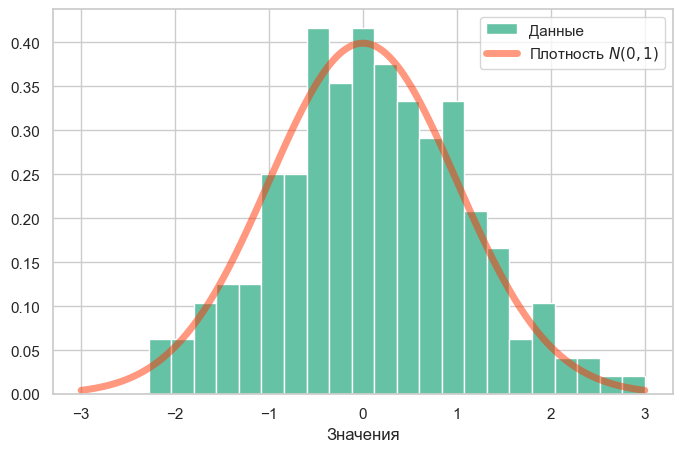

In [13]:
# Сетка для теоретической плотности
grid = np.linspace(-3, 3, 1000)

# # Отрисовка графика
plt.figure(figsize=(8, 5))

plt.hist(data_norm, bins=25, density=True, label="Данные", range=(-3, 3))

plt.plot(
    grid,
    sps.norm().pdf(grid),
    lw=5,
    alpha=0.5,
    label="Плотность $N(0, 1)$",
    color="#FF3300",
)

plt.xlabel("Значения")
plt.legend()

plt.show()

**3.** Вы уже научились генерировать выборку из равномерного распределения. Напишите функцию **`expon`** генерации выборки из экспоненциального распределения, используя задачу из теории вероятностей:

*Если $\xi$ — случайная величина, имеющая абсолютно непрерывное распределение, и $F$ — ее функция распределения, то случайная величина $F(\xi)$ имеет равномерное распределение на $[0, 1]$*.

$\xi$ ~ $Exp(\lambda)$ , тогда $\xi = \frac{-ln(\eta)}{\lambda}$, где $\eta$ ~ $Uni[0, 1]$

In [14]:
def expon(size: int | tuple = 1, lambd: float = 1.0, n_bits: int = 50) -> float | np.ndarray:
    """
    Генерирует выборку из экспоненциального распределения Exp(lambd).

    Параметры
    ---------
    size: Размерность выходного массива (одно число для вектора или кортеж для тензора).
    lambd: Параметр интенсивности (должно быть > 0).
    n_bits: Количество бросков честной монеты (битов) для базовой генерации U(0, 1).

    Возвращает
    ----------
    Сгенерированные значения из экспоненциального распределения.
    """
    return -np.log(uniform(size, n_bits=n_bits)) / lambd

Для $Exp(1)$ сгенерируйте выборку размера 200 и постройте график плотности этого распределения на отрезке $[-0.5, 5]$.

In [15]:
exp_data = expon(200) # Генерируем данные

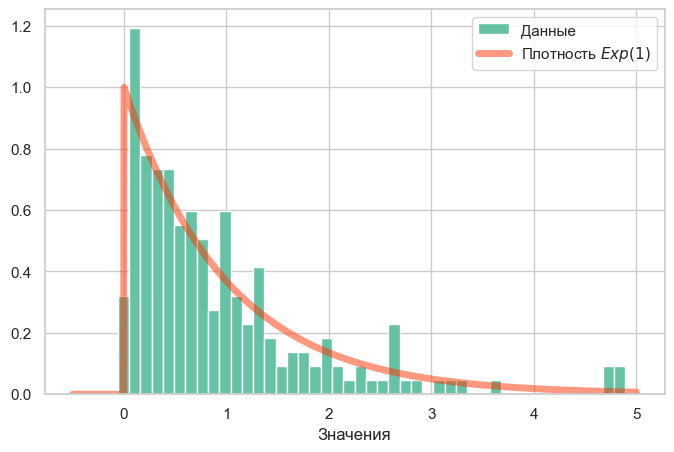

In [16]:
# Сетка для теоретической плотности
grid = np.linspace(-0.5, 5, 1000)

# Отрисовка графика
plt.figure(figsize=(8, 5))

plt.hist(exp_data, bins=50, density=True, label="Данные", range=(-0.5, 5))

plt.plot(
    grid,
    sps.expon().pdf(grid),
    lw=5,
    alpha=0.5,
    label="Плотность $Exp(1)$",
    color="#FF3300",
)

plt.xlabel("Значения")
plt.legend()

plt.show()

**4. Выводы:**

Мы смогли сгенерировать с любой точностью величину с нормальным распределением c помощью монетки. Проанализировали, что точности `n_bits=50` более чем достаточно для величины на отрезке [0, 1]. Потом смогли получить из нормального распределения несложными математическими операциями нормальное и экспоненциальное распределение. Увидели, что данные реально близки к плотности, но все равно есть значимое отклонение из-за небольшой выборки.

---

### Задача 2.

Рассмотрим <a target="_black" href="https://ru.wikipedia.org/wiki/Распределение_Коши">распределение Коши</a> с плотностью
$$p(x) = \frac{1}{\pi(1+x^2)}$$
для $x\in\mathbb{R}$, которое известно своими <a target="_black" href="https://en.wikipedia.org/wiki/Heavy-tailed_distribution">тяжелыми хвостами</a>. Иначе говоря, плотность убывает медленно при $x \to \infty$ (точное определение может различаться для разных источников). Сравните, например, с нормальным или экспоненциальным распределениями. В частности, из-за этого у распределения Коши даже не существует математического ожидания.

За распределение Коши отвечает класс <a target="_black" href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.cauchy.html">`scipy.stats.cauchy`</a>.

**1.** Визуализируйте на одном графики плотности нормального распределения и распределения Коши. Что можно сказать?

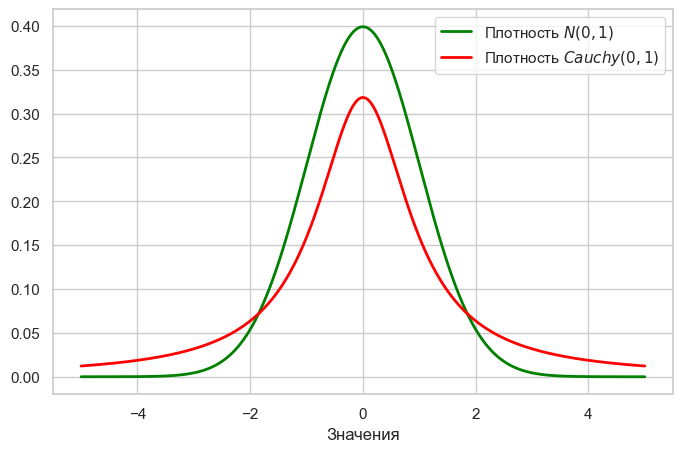

In [17]:
# Сетка для графиков плотности
grid = np.linspace(-5, 5, 1000)

# Отрисовка графиков
plt.figure(figsize=(8, 5))

plt.plot(
    grid,
    sps.norm().pdf(grid),
    lw=2,
    label="Плотность $N(0, 1)$",
    color="green",
)

plt.plot(
    grid,
    sps.cauchy().pdf(grid),
    lw=2,
    label="Плотность $Cauchy(0, 1)$",
    color="red",
)

plt.xlabel("Значения")
plt.legend()

plt.show()

Видно, что при сильном отклонении от 0 у нормального распределения плотность очень близка к 0. Хотя у распределения Коши ниже пик, то есть меньшая плотность около нуля, зато сильно большая чем у нормального при |x| >= 3

**2.** Повторите эксперимент с <a href="https://thetahat.ru/courses/ad/main/9/2_lln" target="_top">занятия</a> про закон больших чисел для распределения Коши. Выполняется ли закон?

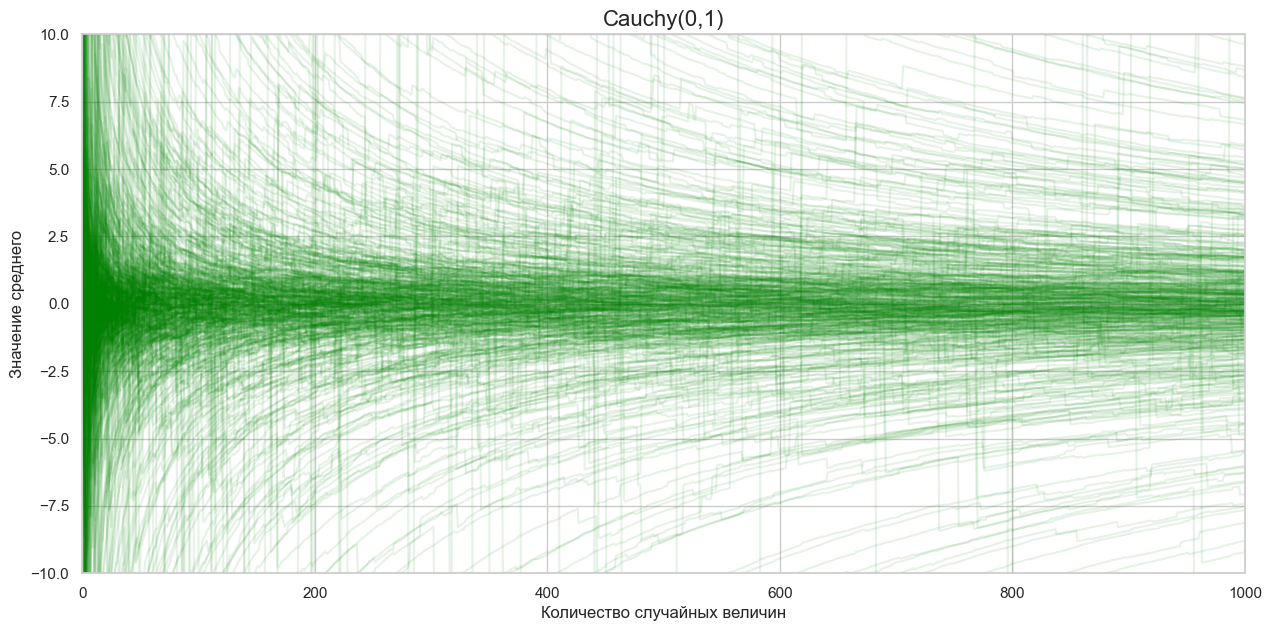

In [18]:
size = 1000
samples_count = 500

# Генерируем выборки и считаем накопленные средние
samples = sps.cauchy().rvs(size=(samples_count, size))
cum_means = samples.cumsum(axis=1) / (np.arange(size) + 1)

# Отрисовка графиков
plt.figure(figsize=(15, 7))

for i in range(samples_count):
    plt.plot(np.arange(size) + 1, cum_means[i], color="green", alpha=0.1)

plt.title("Cauchy(0,1)", fontsize=16)
plt.xlabel("Количество случайных величин")
plt.ylabel("Значение среднего")

plt.xlim((0, size))
plt.ylim((-10, 10))

plt.show()

Закон больших чисел не выволняется, при большом кол-ве случаных величин значение среднего не сходится к матожиданию. Но проблема еще в том, что матожидания в распределении Коши просто не существует, интеграл не существует

**3.** Аналогичным образом проведите эксперимент по изучению сходимости *выборочной* медианы при увеличении размера выборки. Медиану по выборке можно посчитать с помощью <a target="_blank" href="https://numpy.org/doc/stable/reference/generated/numpy.median.html">`np.median`</a>.

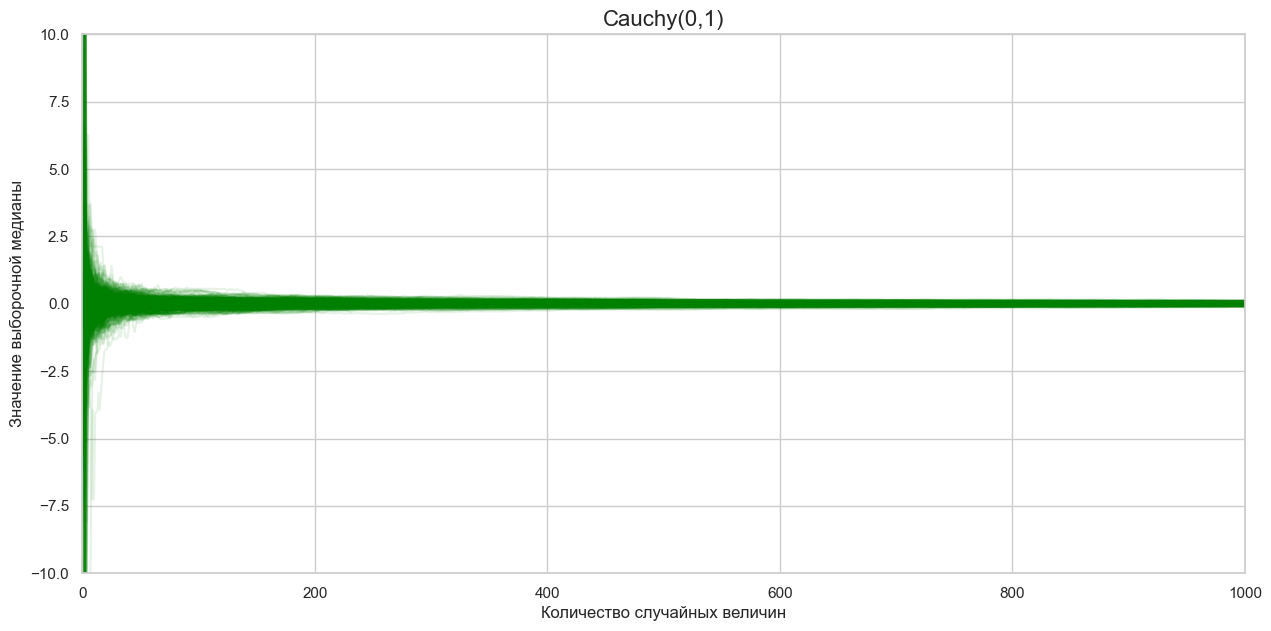

In [19]:
# Считаем выборочные медианы для всех префиксов выборки
sample_medians = np.array([
    np.median(samples[:, :k], axis=1) for k in range(1, size + 1)
]).T

# Отрисовка графиков
plt.figure(figsize=(15, 7))

for i in range(samples_count):
    plt.plot(np.arange(size) + 1, sample_medians[i], color="green", alpha=0.1)

plt.title("Cauchy(0,1)", fontsize=16)
plt.xlabel("Количество случайных величин")
plt.ylabel("Значение выборочной медианы")

plt.xlim((0, size))
plt.ylim((-10, 10))

plt.show()

**4. Вывод:**

Распределение Коши сильно отличается от нормального распределения: оно имеет тяжелые хвосты. Среднее значение при увеличении кол-ва случайных величин Коши не сходится к какому-то числу. Закон больших чисел не выполняется банально из-за того, что у Коши нет математического ожидания.
При этом выборочная медиана сходится к оси симметрии функции плотности, то есть к нулю. Поэтому для Коши стоит использовать медиану, как более стабильную метрику.

---
### Задача 3.

Перед выполнением этой задачи настоятельно рекомендуется посмотреть <a href="https://thetahat.ru/courses/ad/main/9/2_lln" target="_top">ноутбук</a> с лекции про закон больших чисел.

На практике не редко возникает вопрос &mdash; **сколько времени потребуется на сбор данных, чтобы оценить среднее с достаточной точностью**. Для ответа на этот вопрос можно использовать различные теоретические оценки, в частности, неравенство Чебышева.

Другой способ &mdash; смоделировать большое количество выборок. Предположим, что мы сгенерировали $K$ выборок размера $n$ каждая, и $M_{nj}$ &mdash; *выборочное* среднее элементов в $j$-й выборке. Пусть математическое ожидание равно $a$, будем считать его известным в данной задаче. Тогда в качестве меры отклонения от среднего *среднее значение модуля отклонения от $a$*, то есть
$$F(n) = \frac{1}{K}\sum\limits_{j=1}^{K} \left|M_{nj} - a \right|,$$

**1.** Рассмотрим распределения $Bern(a)$ для $a=0.5$. Пусть для нас допустимо отклонение на 0.02, иначе говоря при *истинном* среднем 0.5 мы считаем достаточно точными значения *выборочного* среднего от 0.48 до 0.52. Тогда в качестве *приближения* необходимого размера выборок можно взять наименьшее значение $n$, при котором $F(n) \leqslant 0.02$.

Реализуйте данный эксперимент для $K=500$ и найдите значение $n$. Визуализируйте зависимость $F(n)$ от $n$ в обычном и логарифмическом масштабах (по тем осям, по которым это имеет смысл).

Для реализации без циклов стоит генерировать достаточно большие выборки и использовать функцию `np.where`.

In [20]:
def calc_Fn(a: int, K: int = 500, n: int = 600):
    """
    Вычисляет среднее отклонение выборочных средних от параметра a.

    Параметры
    ---------
    a : int
        Параметр распределения Бернулли.
    K : int
        Число выборок.
    n : int
        Размер каждой выборки.

    Возвращает
    ----------
    np.ndarray
        Массив средних отклонений для каждого объёма выборки от 1 до n.
    """

    # Генерируем K выборок из распределения Бернулли
    samples = sps.bernoulli(p=a).rvs(size=(K, n))

    # Считаем накопленные суммы в каждой выборке
    cum_sums = samples.cumsum(axis=1)

    # Вычисляем выборочные средние для всех объёмов от 1 до n
    mean_samples = cum_sums / np.arange(1, n + 1)

    # Усредняем абсолютные отклонения от a по всем K выборкам
    return np.sum(np.abs(mean_samples - a), axis=0) / K

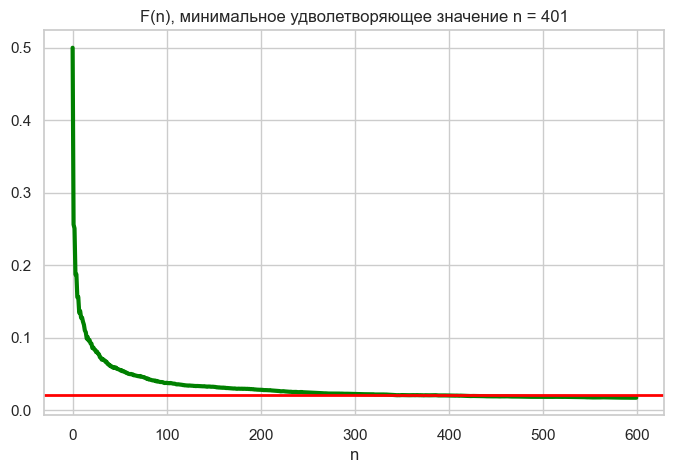

In [21]:
F_1 = calc_Fn(0.5)

# Отрисовка графика
plt.figure(figsize=(8, 5))

plt.plot(
    F_1,
    lw=3,
    color="green",
)

plt.xlabel("n")

plt.axhline(y=0.02, color="red", lw=2)

plt.title(f"F(n), минимальное удволетворяющее значение n = {np.where(F_1 < 0.02)[0][0]}")

plt.show()

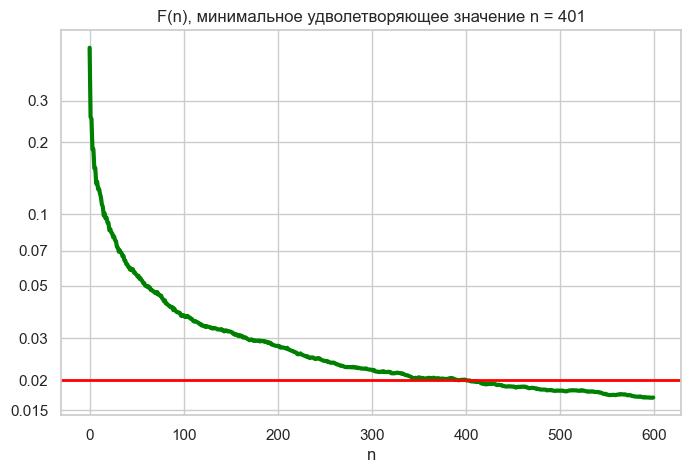

In [22]:
# Создаём фигуру
plt.figure(figsize=(8, 5))

# Отрисовка графика
plt.plot(
    F_1,
    lw=3,
    color="green",
)

plt.xlabel("n")

plt.yscale('log')

plt.title(f"F(n), минимальное удволетворяющее значение n = {np.where(F_1 < 0.02)[0][0]}")

plt.yticks(
    [0.015, 0.02, 0.03, 0.05, 0.07, 0.1, 0.2, 0.3],
    ['0.015', '0.02', '0.03', '0.05', '0.07', '0.1', '0.2', '0.3']
)

plt.axhline(y=0.02, color="red", lw=2)

plt.show()

**2.** Повторите эксперимент из пункта 1 для значений $a$ от 0.05 до 0.95 с шагом 0.05. Визуализируйте зависимость необходимого размера выборки $n$ от значения $a$.

При реализации можно сделать цикл по значениям $a$.

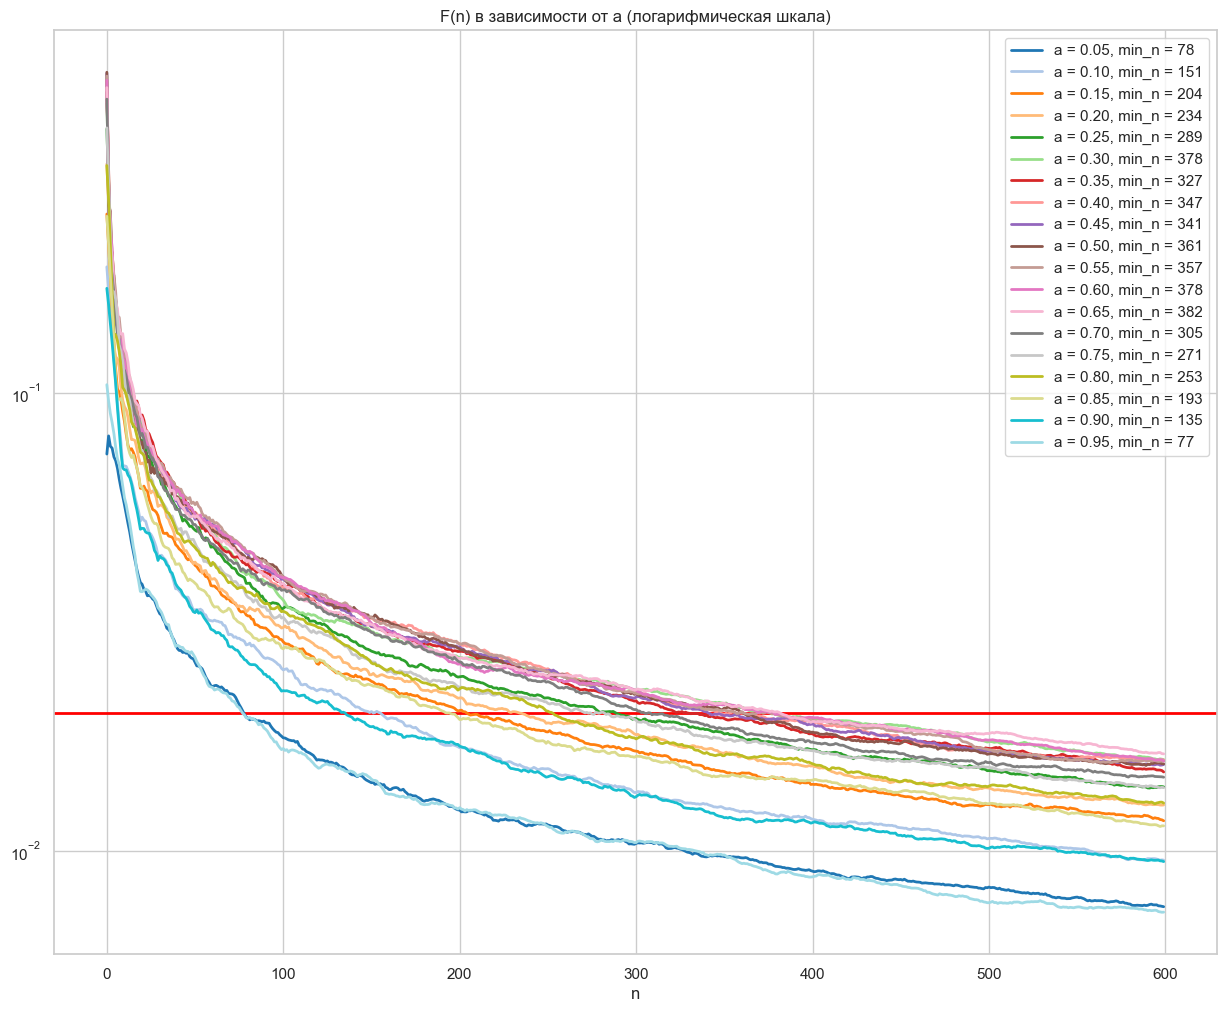

In [23]:
# Задаём набор значений параметра a
list_of_a = np.linspace(0.05, 0.95, 19)

# Отрисовка графика
plt.figure(figsize=(15, 12))

plt.axhline(y=0.02, color="red", lw=2)

# Задаём 19 разных цветов для графиков
colors = plt.cm.tab20(np.linspace(0, 1, 19))

# Строим график F(n) для каждого значения a
for i in range(len(list_of_a)):
    cur_F = calc_Fn(list_of_a[i])
    plt.plot(
        cur_F,
        lw=2,
        color=colors[i],
        label=f"a = {list_of_a[i]:.2f}, min_n = {np.where(cur_F < 0.02)[0][0]}"
    )

plt.xlabel("n")

plt.yscale('log')

plt.legend()

plt.title("F(n) в зависимости от a (логарифмическая шкала)")

plt.show()
    

**3.** В теории часто предполагается независимость элементов выборки, однако, на практике это не всегда так. Исследуем, насколько это влияет на сходимость средних. Повторите эксперимент пункта 1, используя вместо выборки генерацию марковской цепи на значениях 0 и 1 с матрицей переходных вероятностей
$$
\begin{pmatrix}
p & 1-p \\
1-p & p
\end{pmatrix}.
$$

При $p=1/2$ мы получаем генерацию выборки из независимых случайных величин $Bern(1/2)$. При других значениях $p$ мы также получаем случайные величины из $Bern(1/2)$, но они уже зависимы друг с другом.

Проведите эксперимент для значений $p$ от 0.05 до 0.95 с шагом 0.05. Визуализируйте зависимость необходимого размера выборки $n$ от значения $p$.

In [24]:
def generate_markov_chain(
    trans_matrix: list[list[float]],
    start_state: int,
    size: int,
    N: int,
) -> List[int]:
    """
    Генерирует последовательность состояний цепи Маркова.

    Параметры
    ----------
    trans_matrix : list[list[float]]
        Матрица переходных вероятностей.
    start_state : int
        Начальное состояние.
    size : int
        Длина последовательности.
    N : int
        Число состояний.

    Возвращает
    ----------
    List[int]
        Последовательность состояний.
    """
    # Начинаем цепь с заданного состояния
    chain = [start_state]

    # Задаём множество возможных состояний
    states = range(N)

    # Последовательно генерируем следующие состояния
    for _ in range(size - 1):
        # Берём текущее состояние
        current_state_idx = chain[-1]

        # Получаем вероятности перехода из текущего состояния
        next_state_probs = trans_matrix[current_state_idx]

        # Генерируем следующее состояние
        next_state = np.random.choice(states, p=next_state_probs)

        # Добавляем его в цепь
        chain.append(next_state)

    # Возвращаем сгенерированную цепь
    return chain

In [29]:
def calc_Fn_markov(a: float, K: int = 500, n: int = 8500):
    """
    Вычисляет среднее отклонение выборочных средних от 0.5
    для выборок, полученных из цепи Маркова.

    Параметры
    ---------
    a : int
        Вероятность сохранения текущего состояния.
    K : int
        Число сгенерированных цепей.
    n : int
        Длина каждой цепи.

    Возвращает
    ----------
    np.ndarray
        Массив средних отклонений для каждого объёма выборки от 1 до n.
    """

    # Генерируем K цепей Маркова длины n
    samples = np.array([generate_markov_chain([[a, 1 - a], [1 - a, a]],
                                            np.random.choice([0, 1], p=[0.5, 0.5]),
                                            n,
                                            2) for i in range(K)])

    # Считаем накопленные суммы в каждой цепи
    cum_sums = samples.cumsum(axis=1)

    # Вычисляем выборочные средние для всех объёмов от 1 до n
    mean_samples = cum_sums / np.arange(1, n + 1)

    # Усредняем абсолютные отклонения от 0.5 по всем цепям
    return np.sum(np.abs(mean_samples - 0.5), axis=0) / K

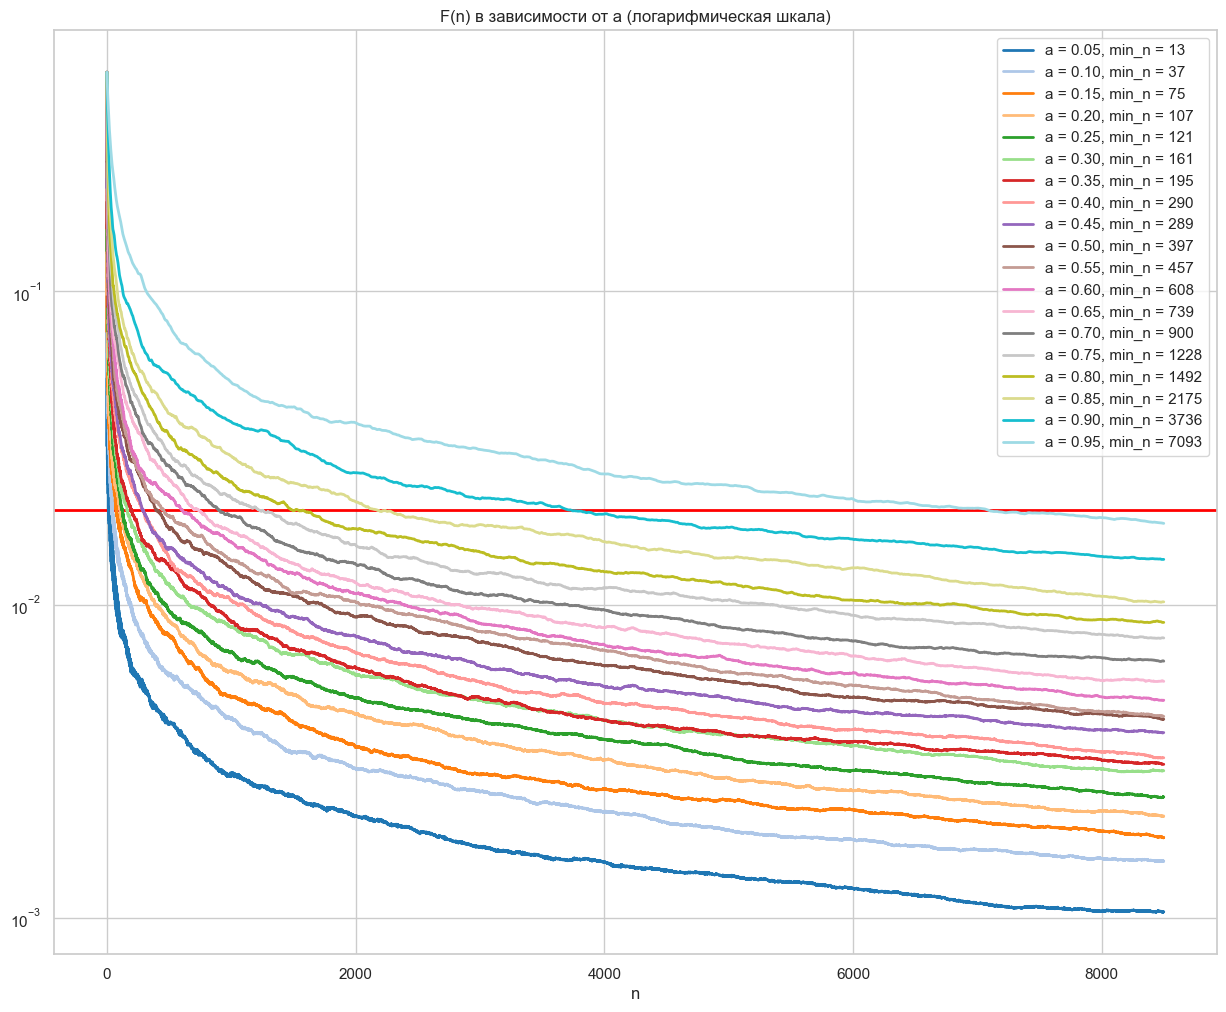

In [28]:
# Задаём набор значений параметра a
list_of_a = np.linspace(0.05, 0.95, 19)

# Отрисовка графика
plt.figure(figsize=(15, 12))

plt.axhline(y=0.02, color="red", lw=2)

# Строим график F(n) для каждого значения a
for i in range(len(list_of_a)):
    cur_F = calc_Fn_markov(list_of_a[i])
    plt.plot(
        cur_F,
        lw=2,
        color=colors[i],
        label=f"a = {list_of_a[i]:.2f}, min_n = {np.where(cur_F < 0.02)[0][0]}"
    )

plt.xlabel("n")

plt.yscale('log')

plt.legend()

plt.title("F(n) в зависимости от a (логарифмическая шкала)")

plt.show()

**4. Выводы:**

Для независимых бернулиевских случайных величин с увеличением размера выборки средневыборочное отклонение от среднего стремиться к нулю, что согласуется с ЗБЧ. Если мы рассмотрим зависимость того, насколько быстро она сходится, то получится, что при значениях дальше от 0.5 скорость схождения увеличивается. Это обуславливается тем, что дисперсия максимальна при $p=0.5$. Если мы рассмотрим марковские цепи, то там средневыборочное стремиться к 0.5. Чем больше параметр p, тем медленнее скорость схождения. Т.к. при малых p модель склонна часто чередоваться, поэтому среднее выборочное будет близко к 0.5. При больших p, цепь наоборот, склонна залипать на своем значении, поэтому средневыборочное будет сильнее отклонятся от 0.5. И нужна намного большая выборка для той же точности.

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД